# Experiment 0 - Baseline

**Pipeline preprocessing:** Tidak ada preprocessing tambahan (hanya grayscale + resize dari loader).

## Setup

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Berjalan di Google Colab. Menyiapkan environment...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    REPO_DIR = '/content/cloud-classification'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/Vuxyn/cloud-classification.git
    else:
        !git -C {REPO_DIR} pull
        
    %cd {REPO_DIR}/notebooks
    
    ZIP_PATH = '/content/drive/MyDrive/GCD-zip.zip'
    EXTRACT_DIR = '/content/GCD-zip'
    
    if os.path.exists(ZIP_PATH):
        if not os.path.exists(EXTRACT_DIR):
            print(f"Mengekstrak {ZIP_PATH} ke {EXTRACT_DIR}...")
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print("Ekstraksi selesai!")
        else:
            print(f"Dataset sudah diekstrak di {EXTRACT_DIR}")
    else:
        print(f"Peringatan: File zip {ZIP_PATH} tidak ditemukan di Google Drive Anda.")
        print("Pastikan nama file zip di Drive utama adalah 'GCD-zip.zip'.")

    # Cek apakah runtime menggunakan GPU
    import subprocess
    try:
        subprocess.check_output('nvidia-smi')
        print("GPU NVIDIA terdeteksi, menginstall cupy...")
        !pip install cupy-cuda12x python-dotenv gdown
    except Exception:
        print("GPU tidak aktif. Menjalankan menggunakan CPU.")
        !pip install python-dotenv gdown

In [2]:
import sys
sys.path.append('..')  # supaya src/ bisa diimport dari notebooks/

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from src.loader import get_dataset_root, load_dataset
from src.image_processing import *


EXPERIMENT_NAME = "baseline"


CuPy tidak tersedia - fallback ke NumPy (CPU)


## Data Loading

In [3]:
DATASET_ROOT = get_dataset_root()
images, labels, filenames = load_dataset(DATASET_ROOT, target_size=(256, 256))
print(f"Dataset loaded: {len(images)} gambar, {len(set(labels))} kelas")


Environment: Lokal
DATASET_ROOT dari .env: D:\INFORMATICS\SEMESTER 4\IMAGE PROCESSING\Praktikum\Project\GCD


Loading cumulus:   0%|          | 0/775 [00:00<?, ?it/s]

Loading cumulus:   9%|▉         | 69/775 [00:00<00:01, 684.46it/s]

Loading cumulus:  21%|██        | 160/775 [00:00<00:00, 811.36it/s]

Loading cumulus:  32%|███▏      | 246/775 [00:00<00:00, 831.66it/s]

...

Loading mixed:  53%|█████▎    | 323/607 [00:00<00:00, 712.28it/s]

Loading mixed:  65%|██████▌   | 396/607 [00:00<00:00, 716.46it/s]

Loading mixed:  78%|███████▊  | 476/607 [00:00<00:00, 740.73it/s]

Loading mixed:  91%|█████████ | 553/607 [00:00<00:00, 748.22it/s]

Dataset loaded: 19000 gambar, 7 kelas, ukuran=(256, 256)
Dataset loaded: 19000 gambar, 7 kelas


## Dataset Visualization & Distribution

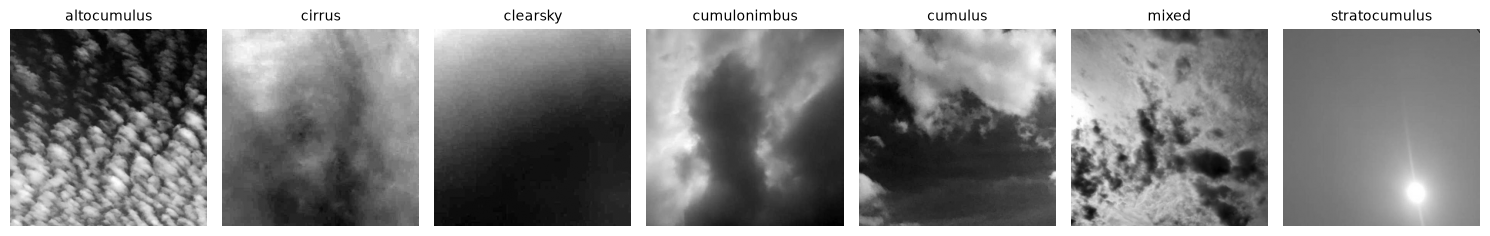

C:\Users\Mahesa\AppData\Local\Temp\ipykernel_42576\492372970.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d')


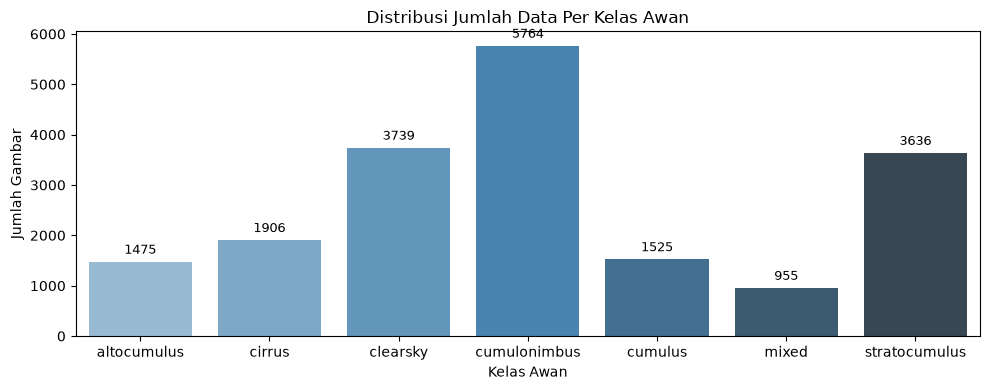

In [4]:
# Tampilkan contoh gambar untuk setiap kelas
unique_labels = sorted(list(set(labels)))
fig, axes = plt.subplots(1, len(unique_labels), figsize=(15, 3))
for i, label in enumerate(unique_labels):
    idx = np.where(labels == label)[0][0]
    img = images[idx]
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
    else:
        axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label, fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Tampilkan bar chart distribusi kelas
plt.figure(figsize=(10, 4))
label_counts = pd.Series(labels).value_counts().sort_index()
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Blues_d')
plt.title('Distribusi Jumlah Data Per Kelas Awan')
plt.xlabel('Kelas Awan')
plt.ylabel('Jumlah Gambar')
for i, count in enumerate(label_counts.values):
    plt.text(i, count + 100, str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Preprocessing Pipeline

In [5]:
# ================================================================
# EDIT BAGIAN INI untuk mengubah pipeline preprocessing
# Tambah, hapus, atau ganti fungsi sesuai experiment
# ================================================================

PIPELINE = []

# ================================================================
# Jangan edit di bawah ini
# ================================================================

def apply_pipeline(image: np.ndarray, pipeline: list) -> np.ndarray:
    for fn in pipeline:
        image = fn(image)
    return image


In [6]:
# Terapkan pipeline ke seluruh dataset
import os
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

def process_one(img):
    return apply_pipeline(img, PIPELINE)

if not PIPELINE:
    images_preprocessed = images.copy()
else:
    if USING_GPU:
        print("Menggunakan ThreadPoolExecutor (GPU aktif)...")
        with ThreadPoolExecutor(max_workers=4) as executor:
            images_preprocessed = list(tqdm(
                executor.map(process_one, images),
                total=len(images),
                desc="Preprocessing"
            ))
    else:
        print("Menggunakan Pemrosesan Sekuensial CPU (mencegah OOM Crash)...")
        images_preprocessed = [process_one(img) for img in tqdm(images, desc="Preprocessing")]
        
    images_preprocessed = np.array(images_preprocessed)


## Visualisasi Preprocessing

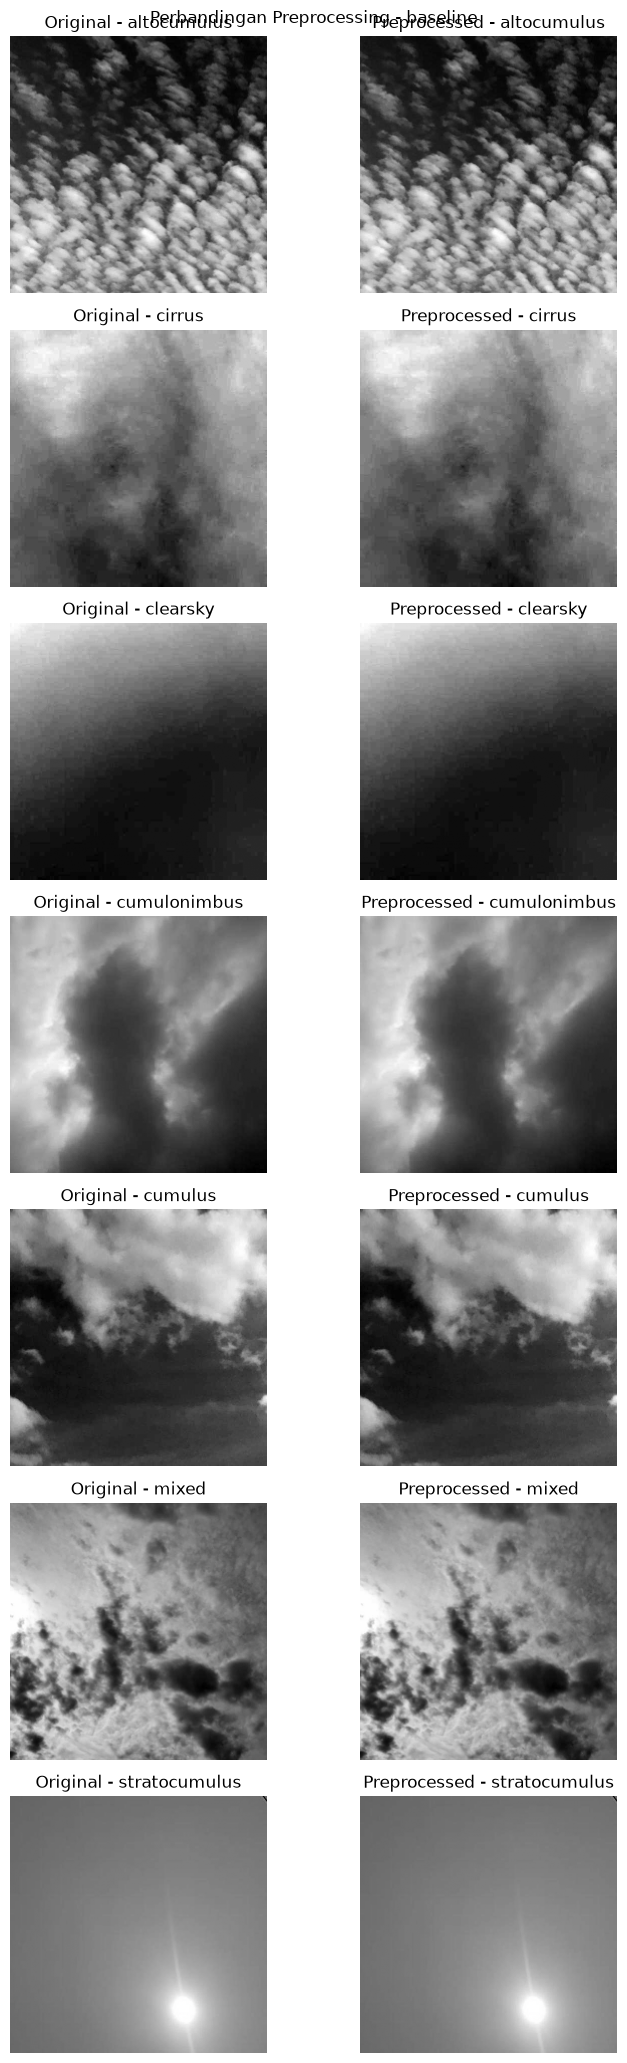

In [7]:
# Tampilkan perbandingan original vs hasil preprocessing
# 1 sample per kelas, 2 kolom: original | preprocessed

unique_labels = sorted(set(labels))
n_classes = len(unique_labels)
fig, axes = plt.subplots(n_classes, 2, figsize=(8, 3 * n_classes))
if n_classes == 1:
    axes = np.array([axes])

for row, label in enumerate(unique_labels):
    idx = next(i for i, lb in enumerate(labels) if lb == label)
    axes[row, 0].imshow(images[idx], cmap='gray')
    axes[row, 0].set_title(f'Original - {label}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(images_preprocessed[idx], cmap='gray')
    axes[row, 1].set_title(f'Preprocessed - {label}')
    axes[row, 1].axis('off')

plt.suptitle(f'Perbandingan Preprocessing - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()


## Feature Extraction (GLCM)

In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan 0, 45, 90, atau 135.")

    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)


def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]


def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]


def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]


def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]


def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]


def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]


def entropyGlcm(matriks):
    return entropy(matriks.ravel())


In [9]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in tqdm(range(len(images_preprocessed)), desc="Extracting GLCM features"):
    # Hitung matriks GLCM
    g0 = glcm(images_preprocessed[i], 0)
    g45 = glcm(images_preprocessed[i], 45)
    g90 = glcm(images_preprocessed[i], 90)
    g135 = glcm(images_preprocessed[i], 135)
    
    # Ekstrak properti on-the-fly untuk menghemat RAM (mencegah crash di Colab)
    Kontras0.append(contrast(g0))
    Kontras45.append(contrast(g45))
    Kontras90.append(contrast(g90))
    Kontras135.append(contrast(g135))
    
    dissimilarity0.append(dissimilarity(g0))
    dissimilarity45.append(dissimilarity(g45))
    dissimilarity90.append(dissimilarity(g90))
    dissimilarity135.append(dissimilarity(g135))
    
    homogenity0.append(homogenity(g0))
    homogenity45.append(homogenity(g45))
    homogenity90.append(homogenity(g90))
    homogenity135.append(homogenity(g135))
    
    entropy0.append(entropyGlcm(g0))
    entropy45.append(entropyGlcm(g45))
    entropy90.append(entropyGlcm(g90))
    entropy135.append(entropyGlcm(g135))
    
    ASM0.append(ASM(g0))
    ASM45.append(ASM(g45))
    ASM90.append(ASM(g90))
    ASM135.append(ASM(g135))
    
    energy0.append(energy(g0))
    energy45.append(energy(g45))
    energy90.append(energy(g90))
    energy135.append(energy(g135))
    
    correlation0.append(correlation(g0))
    correlation45.append(correlation(g45))
    correlation90.append(correlation(g90))
    correlation135.append(correlation(g135))

dataTable = {
    'Filename': filenames,
    'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
csv_path = f'hasil_ekstraksi_{EXPERIMENT_NAME}.csv'
df.to_csv(csv_path, index=False)
print(f'Fitur tersimpan ke {csv_path}')
df.head()


Extracting GLCM features:   0%|          | 0/19000 [00:00<?, ?it/s]

Extracting GLCM features:   0%|          | 7/19000 [00:00<05:05, 62.12it/s]

Extracting GLCM features:   0%|          | 14/19000 [00:00<04:50, 65.42it/s]

Extracting GLCM features:   0%|          | 21/19000 [00:00<04:49, 65.53it/s]

Extracting GLCM features:   0%|          | 28/19000 [00:00<05:13, 60.59it/s]

...

Extracting GLCM features: 100%|█████████▉| 18987/19000 [03:37<00:00, 60.29it/s]

Extracting GLCM features: 100%|█████████▉| 18994/19000 [03:37<00:00, 61.49it/s]

Extracting GLCM features: 100%|██████████| 19000/19000 [03:37<00:00, 87.35it/s]

Fitur tersimpan ke hasil_ekstraksi_baseline.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1_cumulus_000001.jpg,cumulus,4.266238,6.879308,5.158180,9.419608,0.597426,0.515852,0.579409,0.495421,...,0.003706,0.002821,0.063220,0.054036,0.060876,0.053112,0.997258,0.995578,0.996684,0.993945
1,1_cumulus_000002.jpg,cumulus,3.036504,6.479585,5.062316,8.304129,0.648462,0.541533,0.619315,0.537407,...,0.004362,0.003230,0.066660,0.056821,0.066043,0.056831,0.999136,0.998160,0.998561,0.997641
2,1_cumulus_000003.jpg,cumulus,9.158333,18.900515,10.695282,17.573595,0.527355,0.448897,0.531987,0.442087,...,0.003802,0.002602,0.058954,0.051473,0.061661,0.051008,0.997547,0.994926,0.997128,0.995282
3,1_cumulus_000004.jpg,cumulus,5.909681,11.468558,6.869930,11.881261,0.615510,0.520967,0.596584,0.513569,...,0.004209,0.003013,0.064751,0.055480,0.064881,0.054893,0.998506,0.997098,0.998262,0.996994
4,1_cumulus_000005.jpg,cumulus,3.622748,9.158339,6.721844,9.899008,0.650936,0.495088,0.552258,0.500163,...,0.002429,0.002012,0.057151,0.044431,0.049282,0.044857,0.998989,0.997443,0.998125,0.997236


## Feature Selection

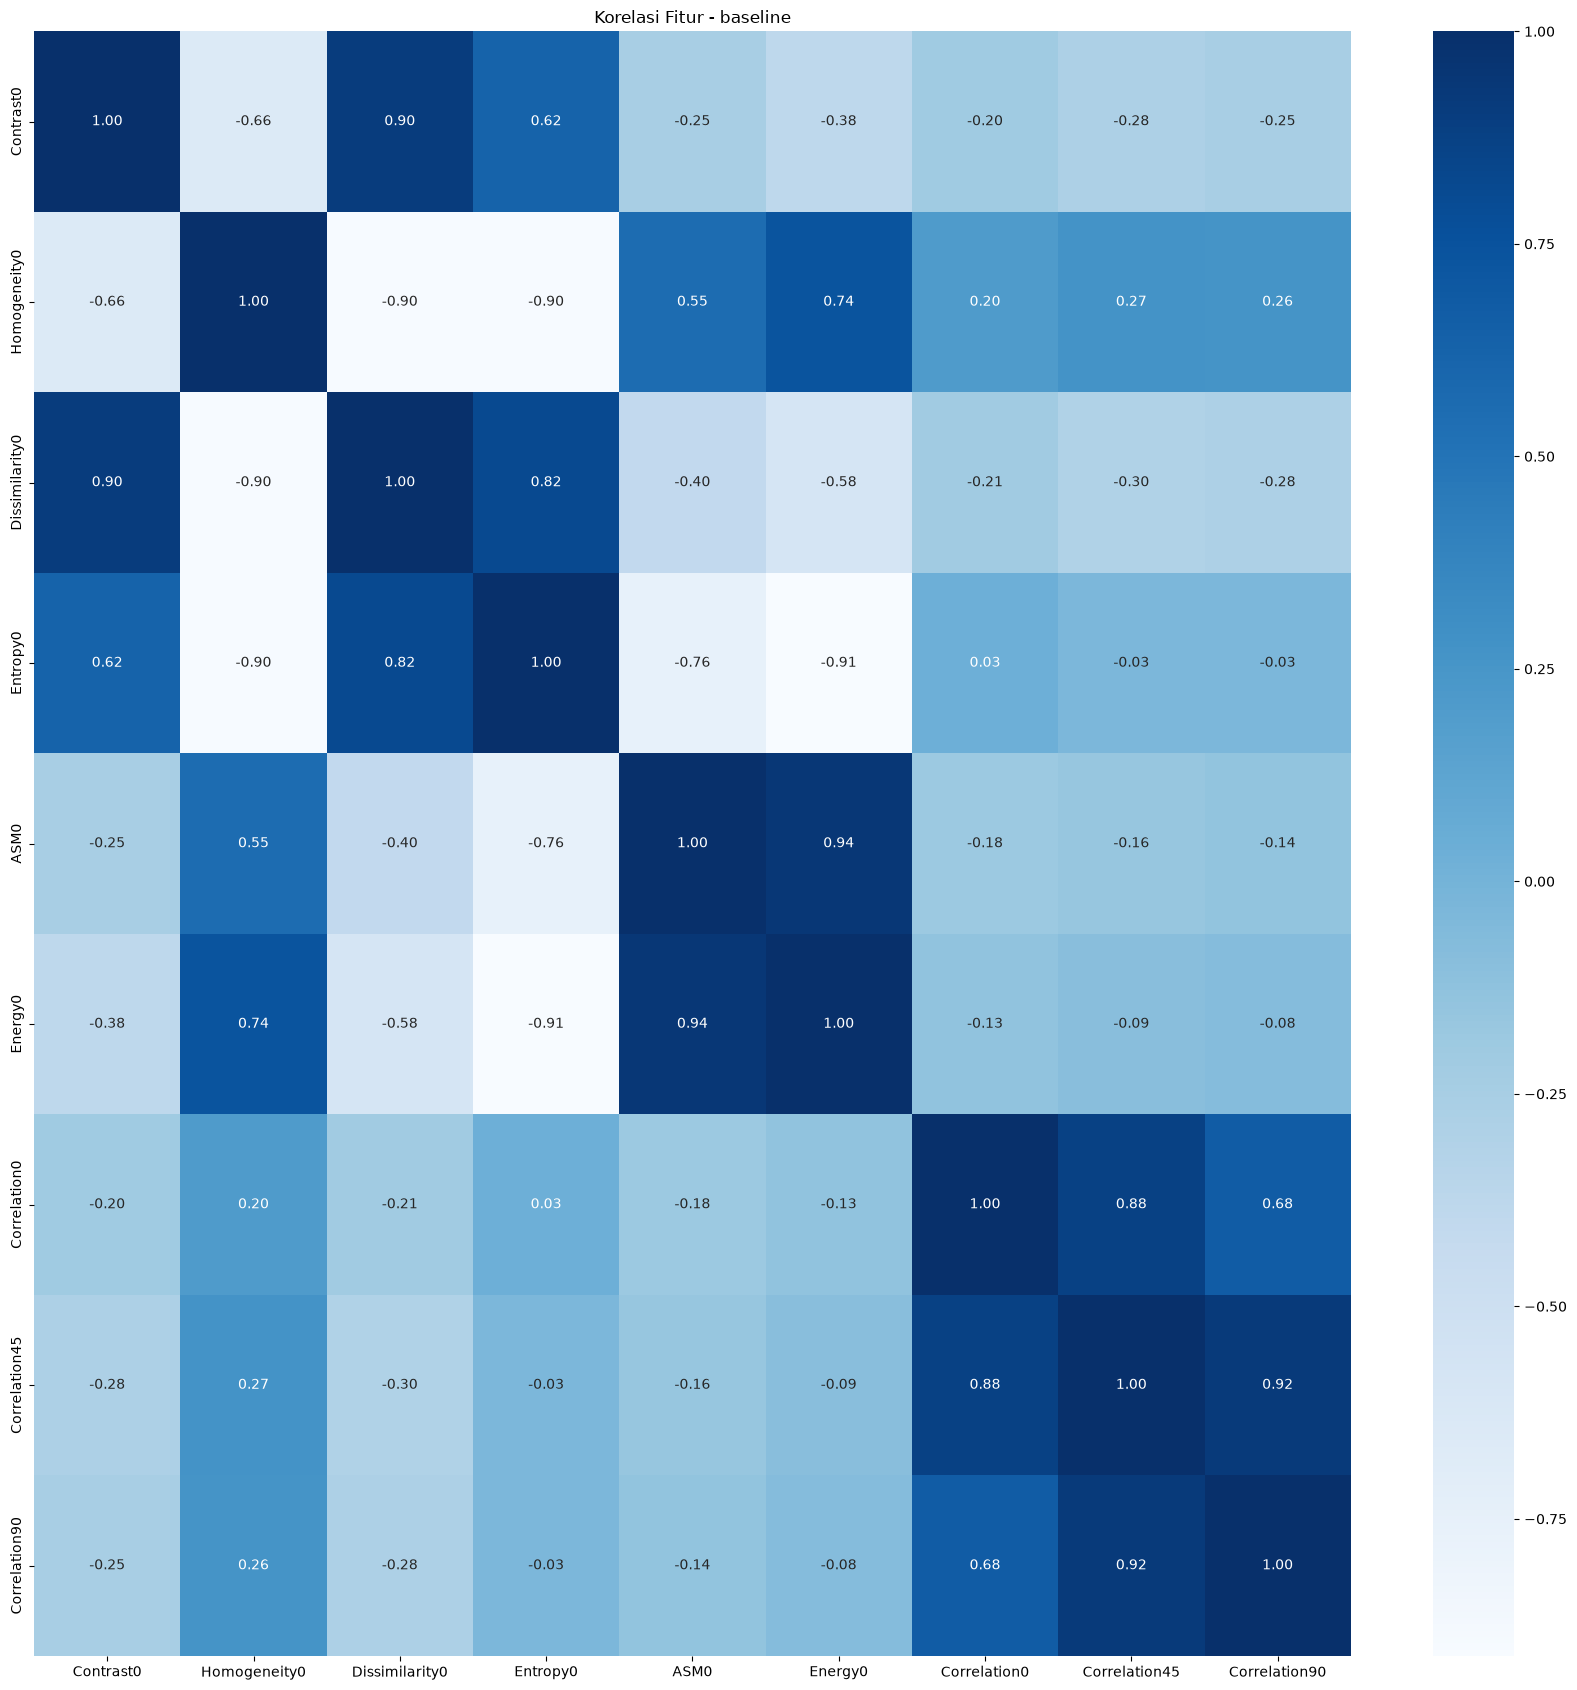

,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Correlation45,Correlation90
0,4.266238,0.597426,1.217310,6.324128,0.003997,0.063220,0.997258,0.995578,0.996684
1,3.036504,0.648462,0.990548,6.298019,0.004444,0.066660,0.999136,0.998160,0.998561
2,9.158333,0.527355,1.755025,6.779807,0.003476,0.058954,0.997547,0.994926,0.997128
3,5.909681,0.615510,1.303738,6.480208,0.004193,0.064751,0.998506,0.997098,0.998262
4,3.622748,0.650936,1.044041,6.503792,0.003266,0.057151,0.998989,0.997443,0.998125
...,...,...,...,...,...,...,...,...,...
18995,3.336504,0.669241,0.970450,6.082961,0.004301,0.065581,0.997189,0.993552,0.996556
18996,5.178370,0.537875,1.414246,6.683481,0.002044,0.045215,0.997002,0.995741,0.997277
18997,3.384161,0.603304,1.114063,6.674435,0.002161,0.046483,0.998833,0.996458,0.997073
18998,6.433379,0.571700,1.381694,6.770346,0.002244,0.047373,0.997779,0.990218,0.990708


In [10]:
# Heatmap korelasi -> drop fitur redundan (threshold 0.95)
correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
selection_feature = []
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = df.drop(columns=['Label', 'Filename']).columns[columns]
x_new = df[select]
y = df['Label']

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Korelasi Fitur - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()

x_new


## Splitting Data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)


(15200, 9)
(3800, 9)


## Feature Normalization

In [12]:
# Z-score normalization - PENTING: fit pada train, apply ke test
mean_train = X_train.mean()
std_train = X_train.std()
X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train


## Modeling

In [13]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)


In [14]:
# Train + evaluate RF
print('------Random Forest - Training Set------')
rf.fit(X_train_norm, y_train)
y_pred_rf_train = rf.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_rf_train)

print('\n------Random Forest - Testing Set------')
y_pred_rf_test = rf.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_rf_test)

# Train + evaluate SVM
print('\n------SVM - Training Set------')
svm.fit(X_train_norm, y_train)
y_pred_svm_train = svm.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_svm_train)

print('\n------SVM - Testing Set------')
y_pred_svm_test = svm.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_svm_test)

# Train + evaluate KNN
print('\n------KNN - Training Set------')
knn.fit(X_train_norm, y_train)
y_pred_knn_train = knn.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_knn_train)

print('\n------KNN - Testing Set------')
y_pred_knn_test = knn.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_knn_test)


------Random Forest - Training Set------


               precision    recall  f1-score   support

  altocumulus       1.00      1.00      1.00      1180
       cirrus       1.00      1.00      1.00      1525
     clearsky       1.00      1.00      1.00      2991
 cumulonimbus       1.00      1.00      1.00      4611
      cumulus       1.00      1.00      1.00      1220
        mixed       1.00      1.00      1.00       764
stratocumulus       1.00      1.00      1.00      2909

     accuracy                           1.00     15200
    macro avg       1.00      1.00      1.00     15200
 weighted avg       1.00      1.00      1.00     15200

[[1180    0    0    0    0    0    0]
 [   0 1525    0    0    0    0    0]
 [   0    0 2991    0    0    0    0]
 [   0    0    0 4611    0    0    0]
 [   0    0    0    0 1220    0    0]
 [   0    0    0    0    0  764    0]
 [   0    0    0    0    0    0 2909]]
Accuracy: 1.0

------Random Forest - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.69      0.62      0.65       295
       cirrus       0.35      0.21      0.26       381
     clearsky       0.54      0.58      0.56       748
 cumulonimbus       0.54      0.66      0.60      1153
      cumulus       0.75      0.76      0.76       305
        mixed       0.55      0.37      0.44       191
stratocumulus       0.44      0.40      0.42       727

     accuracy                           0.54      3800
    macro avg       0.55      0.51      0.53      3800
 weighted avg       0.53      0.54      0.53      3800

[[183  25   5  48  17   8   9]
 [ 36  81  37 157  18  17  35]
 [  5   8 433 145   2   1 154]
 [ 13  66 118 762  16  12 166]
 [  5  20   4  22 233  20   1]
 [ 20  22   9  38  23  70   9]
 [  2  11 190 233   1   0 290]]
Accuracy: 0.54

------SVM - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.73      0.66      0.69      1180
       cirrus       0.44      0.06      0.11      1525
     clearsky       0.52      0.40      0.45      2991
 cumulonimbus       0.47      0.74      0.58      4611
      cumulus       0.79      0.75      0.77      1220
        mixed       0.57      0.27      0.36       764
stratocumulus       0.42      0.42      0.42      2909

     accuracy                           0.51     15200
    macro avg       0.56      0.47      0.48     15200
 weighted avg       0.52      0.51      0.49     15200

[[ 781   24   10  278   32   43   12]
 [ 101   95   98 1000   54   19  158]
 [   2    0 1193 1000    0    0  796]
 [  32   35  380 3417   59   32  656]
 [  34   35    8  163  916   57    7]
 [ 106   25   19  289  105  203   17]
 [  14    2  604 1079    0    0 1210]]
Accuracy: 0.5141447368421053

------SVM - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.74      0.61      0.67       295
       cirrus       0.37      0.07      0.12       381
     clearsky       0.52      0.39      0.44       748
 cumulonimbus       0.47      0.75      0.58      1153
      cumulus       0.77      0.71      0.74       305
        mixed       0.65      0.27      0.38       191
stratocumulus       0.41      0.40      0.41       727

     accuracy                           0.51      3800
    macro avg       0.56      0.46      0.48      3800
 weighted avg       0.51      0.51      0.48      3800

[[180  15   1  76  13   6   4]
 [ 26  28  19 250  18   5  35]
 [  2   0 289 252   1   0 204]
 [  7   8  82 870  15   5 166]
 [  7  15   3  48 218  12   2]
 [ 21   9   5  79  19  52   6]
 [  1   0 155 278   0   0 293]]
Accuracy: 0.5078947368421053

------KNN - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.72      0.74      0.73      1180
       cirrus       0.54      0.40      0.46      1525
     clearsky       0.60      0.73      0.66      2991
 cumulonimbus       0.62      0.73      0.67      4611
      cumulus       0.81      0.79      0.80      1220
        mixed       0.64      0.40      0.50       764
stratocumulus       0.63      0.46      0.53      2909

     accuracy                           0.63     15200
    macro avg       0.65      0.61      0.62     15200
 weighted avg       0.63      0.63      0.63     15200

[[ 873   60   20  140   28   41   18]
 [ 123  610  135  473   43   38  103]
 [  12   54 2196  395    0    4  330]
 [  61  184  580 3375   59   39  313]
 [  29   69    7   95  960   50   10]
 [  86   85   24  152   95  309   13]
 [  27   70  711  771    2    2 1326]]
Accuracy: 0.6348026315789473

------KNN - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.58      0.62      0.60       295
       cirrus       0.31      0.25      0.28       381
     clearsky       0.45      0.53      0.49       748
 cumulonimbus       0.49      0.59      0.54      1153
      cumulus       0.79      0.73      0.76       305
        mixed       0.52      0.28      0.37       191
stratocumulus       0.41      0.30      0.34       727

     accuracy                           0.49      3800
    macro avg       0.51      0.47      0.48      3800
 weighted avg       0.48      0.49      0.48      3800

[[184  19   5  48  13  17   9]
 [ 43  96  45 154  12   8  23]
 [  8  21 397 187   1   1 133]
 [ 30  95 190 680  15  11 132]
 [ 12  24   4  28 223  13   1]
 [ 31  27   5  47  19  54   8]
 [  7  25 243 236   1   0 215]]
Accuracy: 0.48657894736842106


## Evaluation - Confusion Matrix

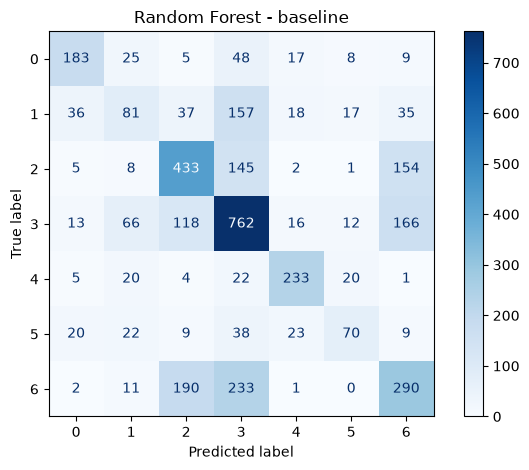

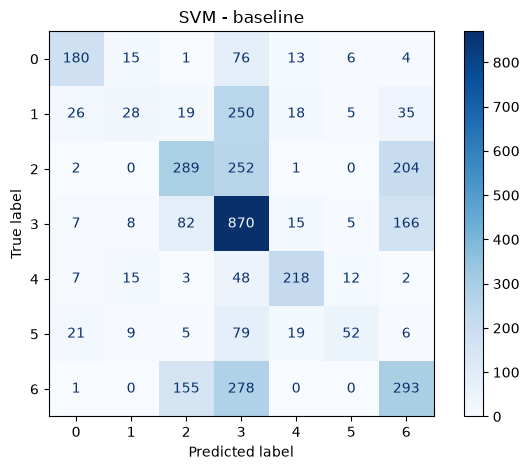

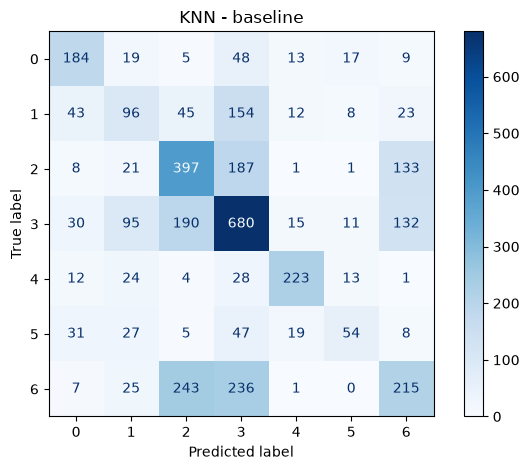

In [15]:
from pathlib import Path

FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(
    y_test, y_pred_rf_test,
    f'Random Forest - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_rf.png'
)
plot_confusion_matrix(
    y_test, y_pred_svm_test,
    f'SVM - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_svm.png'
)
plot_confusion_matrix(
    y_test, y_pred_knn_test,
    f'KNN - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_knn.png'
)


In [16]:
METRICS_PATH = Path('../results/metrics.csv')
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

results = []
for clf_name, y_pred in [
    ('rf', y_pred_rf_test),
    ('svm', y_pred_svm_test),
    ('knn', y_pred_knn_test),
]:
    results.append({
        'experiment_name': EXPERIMENT_NAME,
        'classifier': clf_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

new_rows = pd.DataFrame(results)

# Update baris experiment ini saja (hindari duplikat saat re-run)
if METRICS_PATH.exists() and METRICS_PATH.stat().st_size > 0:
    all_metrics = pd.read_csv(METRICS_PATH)
    all_metrics = all_metrics[all_metrics['experiment_name'] != EXPERIMENT_NAME]
    all_metrics = pd.concat([all_metrics, new_rows], ignore_index=True)
else:
    all_metrics = new_rows

all_metrics.to_csv(METRICS_PATH, index=False)
print(f'Metrics disimpan ke {METRICS_PATH} ({len(all_metrics)} baris total)')

# Jalankan script untuk meng-update tabel di README.md
import subprocess
try:
    subprocess.run(["python", "../src/generate_metrics_table.py"], check=True)
    print("README.md berhasil di-update dengan tabel metrik terbaru!")
except Exception as e:
    print(f"Peringatan: Gagal meng-update README.md: {e}")

all_metrics


Metrics disimpan ke ..\results\metrics.csv (30 baris total)


README.md berhasil di-update dengan tabel metrik terbaru!


,experiment_name,classifier,accuracy,precision,recall,f1
0,experiment1,rf,0.545526,0.529528,0.545526,0.524138
1,experiment1,svm,0.530526,0.506792,0.530526,0.469833
2,experiment1,knn,0.492368,0.469816,0.492368,0.472107
3,experiment2,rf,0.592368,0.578947,0.592368,0.580687
4,experiment2,svm,0.584474,0.566006,0.584474,0.555292
5,experiment2,knn,0.551053,0.536193,0.551053,0.538876
6,experiment3,rf,0.578947,0.565558,0.578947,0.565837
7,experiment3,svm,0.553947,0.538761,0.553947,0.518065
8,experiment3,knn,0.524737,0.510641,0.524737,0.511928
9,experiment4,rf,0.573158,0.559245,0.573158,0.554307


## Analisis

> **[ISI ANALISIS DI SINI]**
> Jelaskan:
> - Pengaruh pipeline preprocessing terhadap fitur GLCM
> - Perbandingan performa antar classifier
> - Kelas mana yang paling sulit diklasifikasikan dan mengapa